In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.layers import *
from tensorflow.keras import models, Model
import qkeras
from qkeras import *

# two new layers
# 1) a input_reduce layer that cut off pixels at n_max_pixels with a feature threshold, output reduced map and a mask (1 for active, 0 for nonactive)
# 2) a mask_remove layer that remove nonactive pixels according to the mask from input_reduce, to be used after a normal qconv2d layer
# so sparse cnn: input -> input_reduce -> qconv2d -> mask_remove -> qactivation -> qpooling -> input_reduce (to generate updated mask) -> qconv2d -> mask_remove -> qactivation -> flatten -> ...

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

n_val = 10000
X_val = X_train[:n_val]
y_val = y_train[:n_val]
X_train = X_train[n_val:]
y_train = y_train[n_val:]

X_train = np.reshape(X_train, (-1,28,28,1)) / 255.
X_val = np.reshape(X_val, (-1,28,28,1)) / 255.
X_test = np.reshape(X_test, (-1,28,28,1)) / 255.

y_train = to_categorical(y_train, 10)
y_val = to_categorical(y_val, 10)
y_test = to_categorical(y_test, 10)

print("X_train.shape: " + str(X_train.shape))
print("y_train.shape: " + str(y_train.shape))
print("X_val.shape: " + str(X_val.shape))
print("y_val.shape: " + str(y_val.shape))
print("X_test.shape: " + str(X_test.shape))
print("y_test.shape: " + str(y_test.shape))

X_train.shape: (50000, 28, 28, 1)
y_train.shape: (50000, 10)
X_val.shape: (10000, 28, 28, 1)
y_val.shape: (10000, 10)
X_test.shape: (10000, 28, 28, 1)
y_test.shape: (10000, 10)


In [ ]:
plt.imshow(X_train[y_train[:,2]==1][0].reshape((28,28,1)))
plt.colorbar()

In [ ]:
def pool_and_pad(img, pool_size, pool_type, target_size=None):
    x = tf.convert_to_tensor(img, dtype=tf.float32)

    k_h = k_w = pool_size

    if pool_type == 'max':
        pooled = tf.nn.max_pool2d(x, ksize=[1, k_h, k_w, 1], strides=[1, k_h, k_w, 1], padding='VALID')
    elif pool_type in ('avg'):
        pooled = tf.nn.avg_pool2d(x, ksize=[1, k_h, k_w, 1], strides=[1, k_h, k_w, 1], padding='VALID')

    old_h = tf.shape(x)[1]
    old_w = tf.shape(x)[2]
    new_h  = tf.shape(pooled)[1]
    new_w  = tf.shape(pooled)[2]

    if target_size is None:
        target_h, target_w = old_h, old_w
    else:
        target_h, target_w = target_size

    pad_y = target_h - new_h
    pad_x = target_w - new_w
    pad_top = pad_y // 2
    pad_bottom = pad_y - pad_top
    pad_left = pad_x // 2
    pad_right = pad_x - pad_left

    padded = tf.pad(
        pooled,
        [[0, 0], # batch
         [pad_top, pad_bottom], # h
         [pad_left, pad_right], # w
         [0, 0]], # c
        mode='CONSTANT',
        constant_values=0
    )

    return padded.numpy()

no. of active pixels (original): 167 / 784 = 0.21301020408163265
no. of active pixels (modified): 35 / 1600 = 0.021875


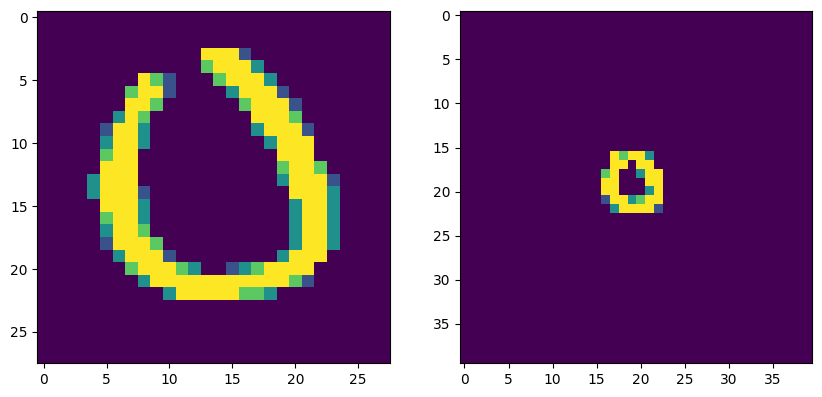

no. of active pixels (original): 165 / 784 = 0.21045918367346939
no. of active pixels (modified): 32 / 1600 = 0.02


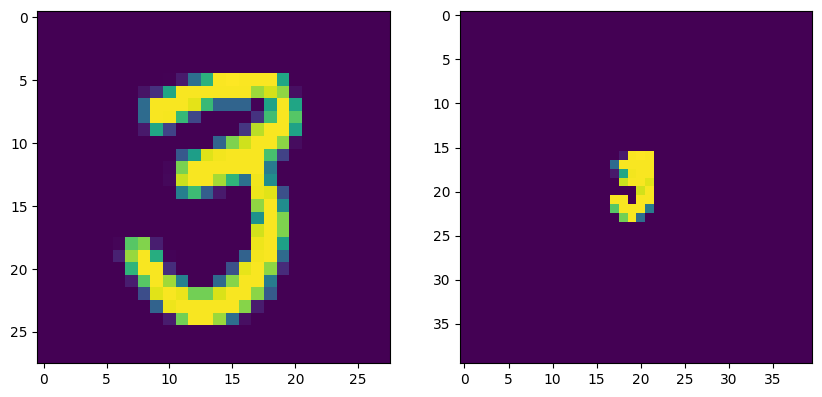

no. of active pixels (original): 227 / 784 = 0.2895408163265306
no. of active pixels (modified): 43 / 1600 = 0.026875


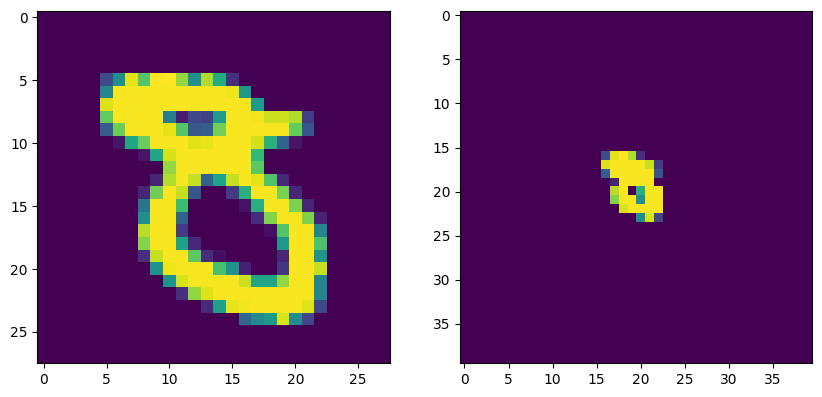

no. of active pixels (original): 156 / 784 = 0.1989795918367347
no. of active pixels (modified): 31 / 1600 = 0.019375


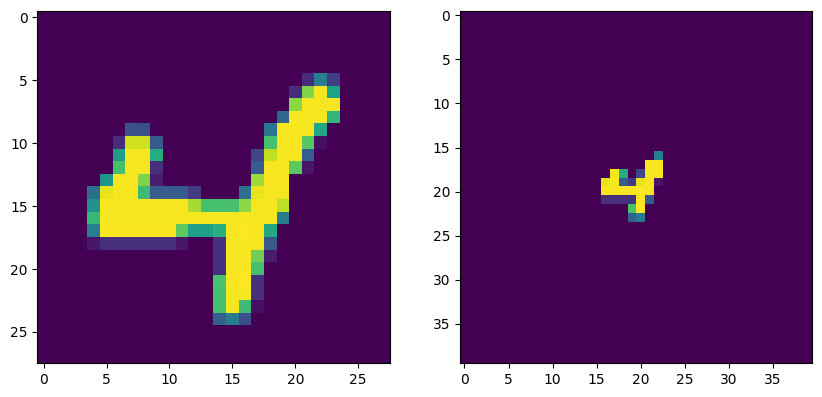

no. of active pixels (original): 167 / 784 = 0.21301020408163265
no. of active pixels (modified): 30 / 1600 = 0.01875


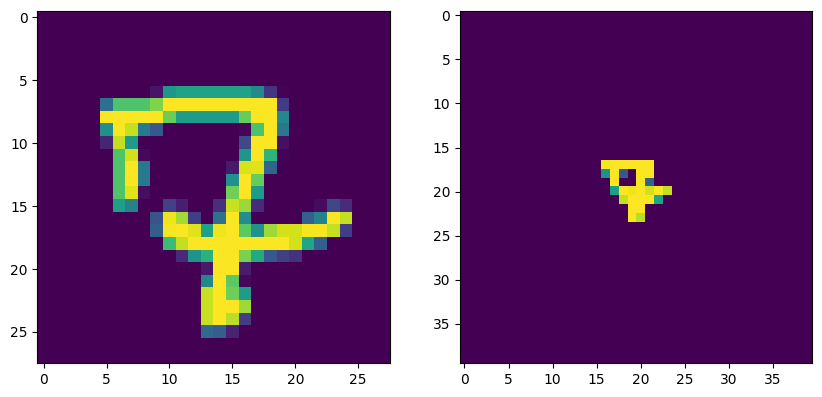

In [36]:
x_train = pool_and_pad(X_train, pool_size=3, pool_type='max', target_size=(40,40))
x_val = pool_and_pad(X_val, pool_size=3, pool_type='max', target_size=(40,40))
x_test = pool_and_pad(X_test, pool_size=3, pool_type='max', target_size=(40,40))

def plot_sparse(x_original, x_modified, n_example):
    img1 = x_original[n_example+10]
    img2 = x_modified[n_example+10]

    print('no. of active pixels (original): ' + str(np.count_nonzero(img1)) + ' / ' + str(img1.size) + ' = ' + str(np.count_nonzero(img1)/img1.size))
    print('no. of active pixels (modified): ' + str(np.count_nonzero(img2)) + ' / ' + str(img2.size) + ' = ' + str(np.count_nonzero(img2)/img2.size))

    fig, axes = plt.subplots(1, 2, figsize=(10,5))
    axes[0].imshow(img1)
    axes[1].imshow(img2)
    plt.show()

for i in range(5):
    plot_sparse(X_train, x_train, i)